## 사계절_가성비 수트셋업 에 대한 판매량 예측 모델 구축

In [27]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import datetime

# 불필요한 경고문 생략(선택)
import warnings
warnings.filterwarnings('ignore')

# 모든 컬럼 출력설정(선택)
pd.set_option('display.max_columns', None)

df = pd.read_csv('사계절_가성비 수트셋업.csv')
df.isna().sum()

기획년도           0
주차_날짜          0
카테고리_통합        0
시즌이월           0
시즌             0
총입고수량          0
판매수량           0
판매액            0
평균택가           0
평균원가           0
주차별_평균_실판매가    0
월별_평균_실판매가     0
시즌별_평균_실판매가    0
총입고원가          0
총입고택가          0
매출원가계          0
판매택가계          0
실판매가           0
할인율            0
누적판매수량         0
누적판매액          0
누적매출원가         0
누적판매택가         0
누적판매율          0
ROI            0
악천후일수          0
평균기온(도)        0
주차             0
dtype: int64

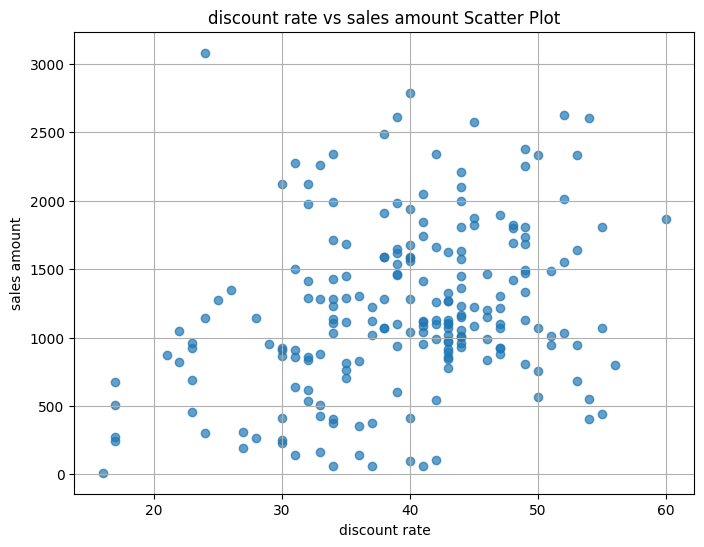

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(df['할인율'], df['판매수량'], alpha=0.7)
plt.xlabel('discount rate')
plt.ylabel('sales amount')
plt.title('discount rate vs sales amount Scatter Plot')
plt.grid(True)
plt.show()

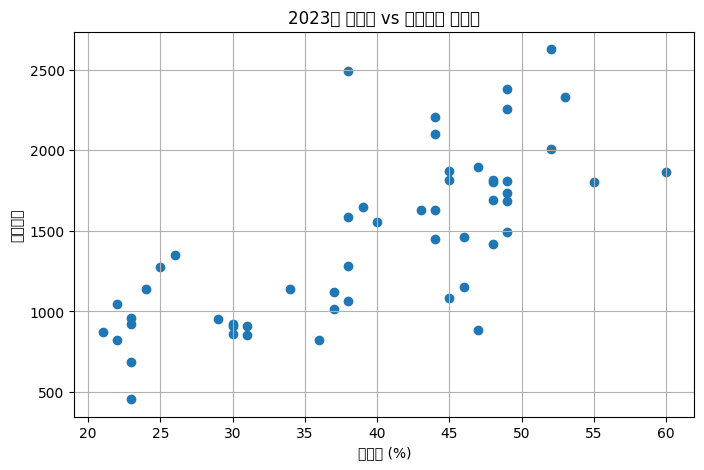

In [21]:
# 2023년 데이터만 필터링
df_2023 = df[df['기획년도'] == 2023]

# 할인율 vs 판매수량 산점도
plt.figure(figsize=(8, 5))
plt.scatter(df_2023['할인율'], df_2023['판매수량'])
plt.xlabel('할인율 (%)')
plt.ylabel('판매수량')
plt.title('2023년 할인율 vs 판매수량 산점도')
plt.grid(True)
plt.show()

In [25]:
# pip install xgboost

In [3]:
df.dtypes

기획년도             int64
주차_날짜           object
카테고리_통합         object
시즌이월            object
시즌              object
총입고수량            int64
판매수량             int64
판매액              int64
평균택가             int64
평균원가             int64
주차별_평균_실판매가    float64
월별_평균_실판매가     float64
시즌별_평균_실판매가    float64
총입고원가            int64
총입고택가            int64
매출원가계            int64
판매택가계            int64
실판매가             int64
할인율              int64
누적판매수량           int64
누적판매액            int64
누적매출원가           int64
누적판매택가           int64
누적판매율          float64
ROI            float64
악천후일수            int64
평균기온(도)        float64
주차               int64
dtype: object

In [12]:
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

df['악천후유무'] = df['악천후일수'].apply(lambda x: 1 if x > 0 else 0)

columns = ['기획년도', '주차', '평균기온(도)', '악천후일수', '할인율', '악천후유무', '판매수량']
df = df[columns]

# #결측치 있으면 전 행으로 채워넣기
# df.fillna(method='ffill', inplace=True)

train_df = df[df['기획년도'] < 2024]
test_df = df[df['기획년도'] == 2024]

X_train = train_df.drop(columns=['판매수량'])
y_train = train_df['판매수량']
X_test = test_df.drop(columns=['판매수량'])
y_test = test_df['판매수량']

model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

performance = {
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2 Score': r2
}

performance

{'MAE': 654.5797952505259,
 'MSE': 570208.994488552,
 'RMSE': 755.121840823421,
 'R2 Score': -6.40714294645018}

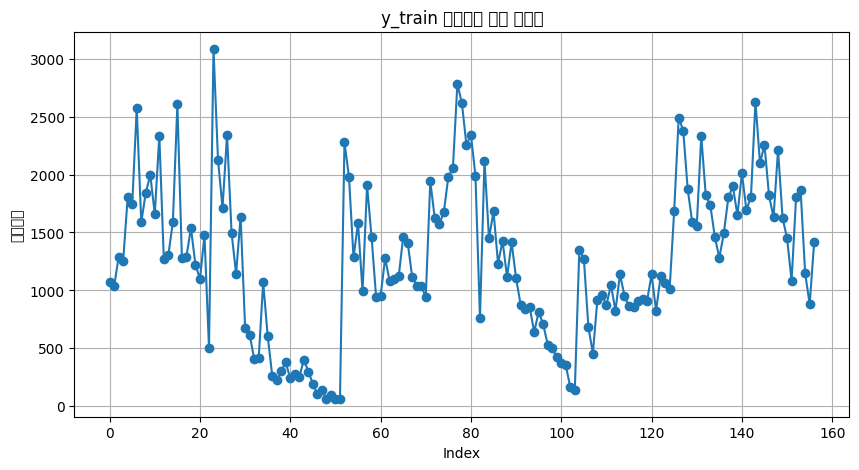

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(y_train.values, marker='o', linestyle='-')
plt.title('y_train 판매수량 라인 그래프')
plt.xlabel('Index')
plt.ylabel('판매수량')
plt.grid(True)
plt.show()

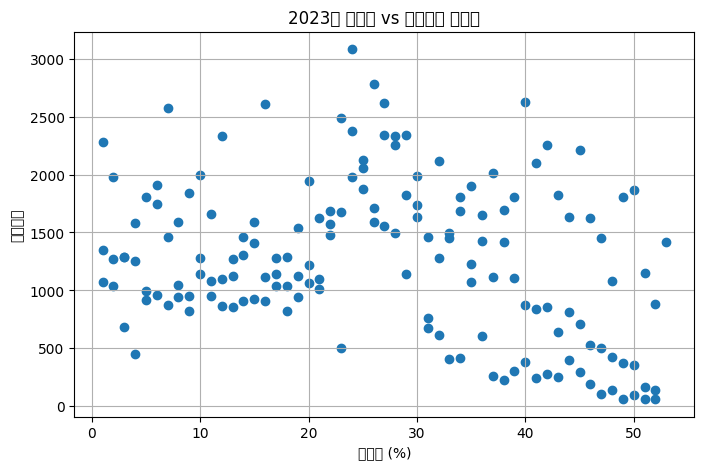

In [23]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df['주차'], train_df['판매수량'])
plt.xlabel('할인율 (%)')
plt.ylabel('판매수량')
plt.title('2023년 할인율 vs 판매수량 산점도')
plt.grid(True)
plt.show()

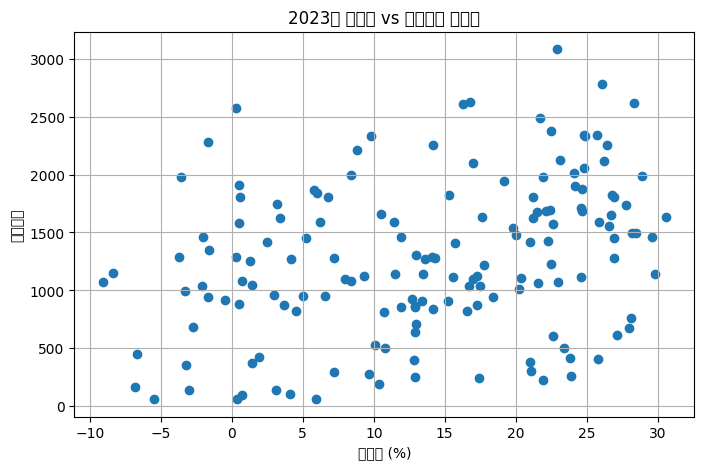

In [24]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df['평균기온(도)'], train_df['판매수량'])
plt.xlabel('할인율 (%)')
plt.ylabel('판매수량')
plt.title('2023년 할인율 vs 판매수량 산점도')
plt.grid(True)
plt.show()

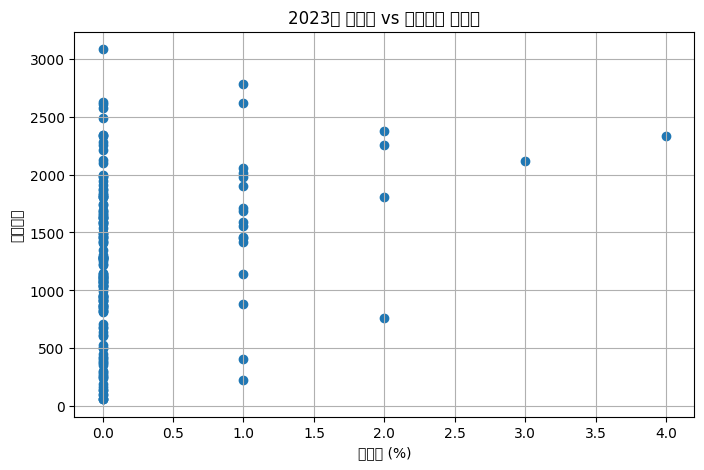

In [25]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df['악천후일수'], train_df['판매수량'])
plt.xlabel('할인율 (%)')
plt.ylabel('판매수량')
plt.title('2023년 할인율 vs 판매수량 산점도')
plt.grid(True)
plt.show()

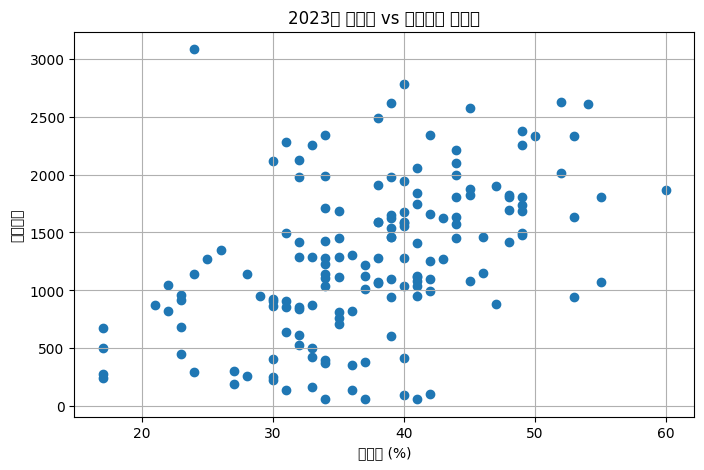

In [26]:
plt.figure(figsize=(8, 5))
plt.scatter(train_df['할인율'], train_df['판매수량'])
plt.xlabel('할인율 (%)')
plt.ylabel('판매수량')
plt.title('2023년 할인율 vs 판매수량 산점도')
plt.grid(True)
plt.show()

In [27]:
# pip install lightgbm

In [ ]:
import lightgbm as lgb
from sklearn.ensemble import RandomForestRegressor

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, learning_rate=0.1, max_depth=4, n_jobs=-1, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=50, learning_rate=0.1, max_depth=4, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train) 
    y_pred = model.predict(X_test) 
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

import pprint
pprint.pprint(results)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000025 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 144
[LightGBM] [Info] Number of data points in the train set: 157, number of used features: 6
[LightGBM] [Info] Start training from score 1273.834395
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: 

In [15]:
from sklearn.model_selection import GridSearchCV

param_grids = {
    'XGBoost': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 500],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [4, 6, 8, 10]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 500],
        'max_depth': [4, 6, 8, 10, None]
    }
}

models = {
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_jobs=-1, random_state=42),
    'LightGBM': lgb.LGBMRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(n_jobs=-1, random_state=42)
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 하이퍼파라미터 튜닝 중...")
    
    grid_search = GridSearchCV(model, param_grids[name], scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    
    best_params[name] = grid_search.best_params_
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
import pprint
pprint.pprint(best_scores)

XGBoost 하이퍼파라미터 튜닝 중...
LightGBM 하이퍼파라미터 튜닝 중...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 144
[LightGBM] [Info] Number of data points in the train set: 157, number of used features: 6
[LightGBM] [Info] Start training from score 1273.834395
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# 랜덤 서치용 하이퍼파라미터 범위 정의
param_distributions = {
    'XGBoost': {
        'n_estimators': randint(100, 1000),         
        'learning_rate': uniform(0.01, 0.3),    
        'max_depth': randint(3, 15)               
    },
    'LightGBM': {
        'n_estimators': randint(100, 1000),
        'learning_rate': uniform(0.01, 0.3),
        'max_depth': randint(3, 15)
    },
    'RandomForest': {
        'n_estimators': randint(100, 1000),
        'max_depth': randint(3, 15)
    }
}

best_params = {}
best_scores = {}

for name, model in models.items():
    print(f"{name} 랜덤 서치 중...")
    
    random_search = RandomizedSearchCV(
        model, 
        param_distributions[name], 
        n_iter=50,  
        scoring='neg_mean_absolute_error',
        cv=3,
        n_jobs=-1,
        random_state=42
    )
    
    random_search.fit(X_train, y_train)
    best_params[name] = random_search.best_params_
    
    best_model = random_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    best_scores[name] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2 Score': r2
    }

print("\n최적 하이퍼파라미터:")
print(best_params)

print("\n최적 모델 성능 평가:")
pprint.pprint(best_scores)


XGBoost 랜덤 서치 중...
LightGBM 랜덤 서치 중...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 144
[LightGBM] [Info] Number of data points in the train set: 157, number of used features: 6
[LightGBM] [Info] Start training from score 1273.834395
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

In [8]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

MAE: 855.82
MSE: 771208.41
RMSE: 878.18
R² Score: -9.02


## 강화학습 환경 구축

- 성능 베스트 회귀 모델 선정해서 best_rf_model로 저장

In [22]:
best_rf_model = RandomForestRegressor(n_estimators=50, max_depth=4, random_state=42, n_jobs=-1)
best_rf_model.fit(X_train, y_train)

RandomForestRegressor(max_depth=4, n_estimators=50, n_jobs=-1, random_state=42)

In [ ]:
importances = best_rf_model.feature_importances_

feature_names = X_train.columns if hasattr(X_train, 'columns') else [f'feature_{i}' for i in range(X_train.shape[1])]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

   Feature  Importance
1       주차    0.359444
0     기획년도    0.300524
2  평균기온(도)    0.265473
4      할인율    0.074559
3    악천후일수    0.000000


In [24]:
import gymnasium
print(gymnasium.__version__)

1.0.0


- 주차 상태와 최적값 미스싱크 해결

In [ ]:
# import gymnasium as gym
# from gymnasium import spaces
# import numpy as np

# class RetailEnv(gym.Env):
#     def __init__(self, model, max_discount, target_sales, initial_sales, price, temperature_list, weather_list, lambda_init=0.1):
#         super(RetailEnv, self).__init__()

#         self.model = model
#         self.discount_actions = [i for i in range(0, max_discount + 5, 5)]
#         self.lambda_actions = [-0.01, 0, 0.01]
#         self.actions = [(d, l) for d in self.discount_actions for l in self.lambda_actions]
#         self.action_space = spaces.Discrete(len(self.actions))

#         self.observation_space = spaces.Box(
#             low=np.array([2021, 1, 0, -10, 0, 0, -np.inf, 0, 0, 0]),
#             high=np.array([2030, 52, 52, 40, max_discount, np.inf, np.inf, 1, np.inf, 7]),
#             dtype=np.float32
#         )

#         self.target_sales = target_sales
#         self.cumulative_sales = initial_sales
#         self.cumulative_revenue = 0
#         self.price = price
#         self.lambda_value = lambda_init

#         self.temperature_list = temperature_list
#         self.weather_list = weather_list

#         self.reset()

#     def reset(self, seed=None, options=None):
#         self.year = 2024
#         self.week = 1
#         self.discount = 0
#         self.cumulative_sales = 0
#         self.cumulative_revenue = 0
#         self.remaining_weeks = 52 - self.week  # ✅ 수정됨
#         self.temperature_index = 0
#         self.weather_index = 0
#         self.lambda_value = min(1.0, max(0.0, self.lambda_value))

#         self.temperature = self.temperature_list[self.temperature_index]
#         self.weather = self.weather_list[self.weather_index]
#         self.sales_gap = self.target_sales - self.cumulative_sales

#         return self._get_state(), {}

#     def step(self, action_index):
#         terminated = self.week > 52
#         truncated = False
#         if terminated:
#             return self._get_state(), 0, terminated, truncated, {
#                 'predicted_sales': 0,
#                 'cumulative_revenue': self.cumulative_revenue
#             }

#         discount_action, lambda_action = self.actions[action_index]
#         self.discount = discount_action
#         self.lambda_value = max(0, self.lambda_value + lambda_action)

#         X_input = np.array([[self.year, self.week, self.temperature, self.weather, self.discount]])
#         predicted_sales = self.model.predict(X_input)[0]

#         revenue = self.price * (1 - self.discount / 100) * predicted_sales
#         self.cumulative_revenue += revenue
#         self.cumulative_sales += predicted_sales
#         self.sales_gap = self.target_sales - self.cumulative_sales

#         reward = self.cumulative_revenue - self.lambda_value * abs(self.sales_gap)

#         if not terminated:
#             self.week += 1
#             self.remaining_weeks -= 1  # ✅ 같이 업데이트
#             self.temperature_index = min(self.temperature_index + 1, len(self.temperature_list) - 1)
#             self.weather_index = min(self.weather_index + 1, len(self.weather_list) - 1)
#             self.temperature = self.temperature_list[self.temperature_index]
#             self.weather = self.weather_list[self.weather_index]

#         return self._get_state(), reward, terminated, truncated, {
#             'predicted_sales': predicted_sales,
#             'cumulative_revenue': self.cumulative_revenue
#         }

#     def _get_state(self):
#         return np.array([
#             self.year, self.week, self.remaining_weeks, self.temperature,
#             self.discount, self.cumulative_sales, self.sales_gap, self.lambda_value,
#             self.cumulative_revenue, self.weather
#         ], dtype=np.float32)

#     def render(self):
#         print(f'년도: {self.year}, 주차: {self.week}, 남은 주차: {self.remaining_weeks}, 할인율: {self.discount}%, '
#               f'누적 판매량: {self.cumulative_sales:.2f}, 목표 판매량 차이: {self.sales_gap:.2f}, λ: {self.lambda_value:.2f}, '
#               f'기온: {self.temperature}, 악천후일수: {self.weather}, 누적매출: {self.cumulative_revenue:,.0f}원')


In [25]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np

class RetailEnv(gym.Env):
    def __init__(self, model, max_discount, target_sales, initial_sales, price, temperature_list, weather_list, lambda_init=0.1):
        super(RetailEnv, self).__init__()

        self.model = model
        self.discount_actions = [i for i in range(0, max_discount + 5, 5)]
        self.lambda_actions = [-0.01, 0, 0.01]
        self.actions = [(d, l) for d in self.discount_actions for l in self.lambda_actions]
        self.action_space = spaces.Discrete(len(self.actions))

        self.observation_space = spaces.Box(
            low=np.array([2021, 0, 0, -10, 0, 0, -np.inf, 0, 0, 0]),
            high=np.array([2030, 21, 21, 40, max_discount, np.inf, np.inf, 1, np.inf, 7]),
            dtype=np.float32
        )

        self.target_sales = target_sales
        self.initial_sales = initial_sales
        self.price = price
        self.lambda_value = lambda_init

        self.temperature_list = temperature_list
        self.weather_list = weather_list

        self.reset()

    def reset(self, seed=None, options=None):
        self.year = 2024
        self.week = 0
        self.discount = 0
        self.cumulative_sales = self.initial_sales
        self.cumulative_revenue = 0
        self.remaining_weeks = 21
        self.lambda_value = min(1.0, max(0.0, self.lambda_value))

        return self._get_state(), {}

    def step(self, action_index):
        # 주차를 먼저 업데이트
        self.week += 1
        if self.remaining_weeks > 0:
            self.remaining_weeks -= 1

        # 인덱스 계산
        week_idx = min(self.week - 1, len(self.temperature_list) - 1)
        temperature = self.temperature_list[week_idx]
        weather = self.weather_list[week_idx]

        discount_action, lambda_action = self.actions[action_index]
        self.discount = discount_action
        self.lambda_value = max(0, self.lambda_value + lambda_action)

        X_input = np.array([[self.year, self.week, temperature, weather, self.discount]])
        predicted_sales = self.model.predict(X_input)[0]

        revenue = self.price * (1 - self.discount / 100) * predicted_sales
        self.cumulative_revenue += revenue
        self.cumulative_sales += predicted_sales
        sales_gap = self.target_sales - self.cumulative_sales

        reward = self.cumulative_revenue - self.lambda_value * abs(sales_gap)

        terminated = self.week >= 21
        truncated = False

        next_state = self._get_state()

        return next_state, reward, terminated, truncated, {
            'predicted_sales': predicted_sales,
            'cumulative_revenue': self.cumulative_revenue
        }

    def _get_state(self):
        week_idx = min(self.week - 1, len(self.temperature_list) - 1)
        temperature = self.temperature_list[week_idx]
        weather = self.weather_list[week_idx]

        return np.array([
            self.year, self.week, self.remaining_weeks, temperature,
            self.discount, self.cumulative_sales, self.target_sales - self.cumulative_sales, self.lambda_value,
            self.cumulative_revenue, weather
        ], dtype=np.float32)

    def render(self):
        week_idx = min(self.week - 1, len(self.temperature_list) - 1)
        temperature = self.temperature_list[week_idx]
        weather = self.weather_list[week_idx]

        print(f'년도: {self.year}, 주차: {self.week}, 남은 주차: {self.remaining_weeks}, 할인율: {self.discount}%, '
              f'누적 판매량: {self.cumulative_sales:.2f}, 목표 판매량 차이: {self.target_sales - self.cumulative_sales:.2f}, λ: {self.lambda_value:.2f}, '
              f'기온: {temperature}, 악천후일수: {weather}, 누적매출: {self.cumulative_revenue:,.0f}원')


## 실험

In [26]:
# 실험 코드
from gymnasium import spaces
import numpy as np

# 환경 설정용 리스트 (1~52주차용)
temperature_list = [-1.1, 1.1, -4.9, 2.1, 2.2, 5.3, 3.6, 2.6, 4.5, 7.4, 7.9, 10.2, 13.9, 16, 16.4, 16.7, 19.7, 15.8, 17, 20.7, 20.3, 22.4, 25, 26.5, 25.3, 24.7, 25.5, 26.8, 27.7, 29.2, 29.8, 30.3, 29.1, 27.9, 26.2, 27.6, 26.5, 22.2, 18.7, 17.8, 18.3, 14.4, 16, 11.4, 15.2, 6.3, 3.8, 3.2, 1, -0.6, -0.9, 2.4]
weather_list = [0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 1, 2, 3, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0]

# ✅ 환경 생성
env = RetailEnv(
    model=best_rf_model,
    max_discount=90,
    target_sales=8020,
    initial_sales=0,
    price=89000,
    temperature_list=temperature_list,
    weather_list=weather_list
)

state, _ = env.reset()
print(f'✅ 초기 상태: {state}\n')
print("🎯 21주 실험 시작:")

for _ in range(21):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    env.render()
    if terminated:
        break

print("\n🎯 21주 완료, 종료!")

✅ 초기 상태: [2.024e+03 0.000e+00 2.100e+01 2.400e+00 0.000e+00 0.000e+00 8.020e+03
 1.000e-01 0.000e+00 0.000e+00]

🎯 21주 실험 시작:
년도: 2024, 주차: 1, 남은 주차: 20, 할인율: 55%, 누적 판매량: 265.47, 목표 판매량 차이: 7754.53, λ: 0.09, 기온: -1.1, 악천후일수: 0, 누적매출: 10,632,258원
년도: 2024, 주차: 2, 남은 주차: 19, 할인율: 80%, 누적 판매량: 512.76, 목표 판매량 차이: 7507.24, λ: 0.10, 기온: 1.1, 악천후일수: 0, 누적매출: 15,033,921원
년도: 2024, 주차: 3, 남은 주차: 18, 할인율: 25%, 누적 판매량: 700.25, 목표 판매량 차이: 7319.75, λ: 0.10, 기온: -4.9, 악천후일수: 0, 누적매출: 27,549,002원
년도: 2024, 주차: 4, 남은 주차: 17, 할인율: 80%, 누적 판매량: 1010.28, 목표 판매량 차이: 7009.72, λ: 0.11, 기온: 2.1, 악천후일수: 0, 누적매출: 33,067,525원
년도: 2024, 주차: 5, 남은 주차: 16, 할인율: 40%, 누적 판매량: 1285.60, 목표 판매량 차이: 6734.40, λ: 0.10, 기온: 2.2, 악천후일수: 0, 누적매출: 47,769,697원
년도: 2024, 주차: 6, 남은 주차: 15, 할인율: 30%, 누적 판매량: 1585.84, 목표 판매량 차이: 6434.16, λ: 0.10, 기온: 5.3, 악천후일수: 0, 누적매출: 66,474,560원
년도: 2024, 주차: 7, 남은 주차: 14, 할인율: 45%, 누적 판매량: 1862.80, 목표 판매량 차이: 6157.20, λ: 0.10, 기온: 3.6, 악천후일수: 2, 누적매출: 80,031,728원
년도: 2024, 주차: 8, 남은 주차: 13, 

## DQN 실행

In [27]:
import numpy as np
import torch
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

# 환경이 정상적으로 강화학습과 호환되는지 체크
check_env(env, warn=True)

# DQN 모델 정의 및 학습
model = DQN(
    "MlpPolicy",        # 다층 퍼셉트론 신경망 사용
    env,                # 학습할 환경
    learning_rate=0.001, # 학습률 (튜닝 가능)
    buffer_size=50000,   # 리플레이 메모리 크기
    learning_starts=1000,# 학습 시작 스텝
    batch_size=32,       # 배치 크기
    gamma=0.99,          # 할인율 (미래 보상을 고려하는 정도)
    exploration_fraction=0.1, # 탐험 비율
    exploration_final_eps=0.02, # 최소 탐험값
    target_update_interval=500,# 타겟 네트워크 업데이트 주기
    verbose=1,           # 학습 로그 출력
    tensorboard_log="./dqn_retail_logs/"  # 로그 저장 경로
)

# 모델 학습 진행
TIMESTEPS = 50000  # 학습 스텝 수 (튜닝 가능)
model.learn(total_timesteps=TIMESTEPS)

# 학습된 모델 저장
model.save("dqn_retail_discount")

# 학습된 모델 로드
model = DQN.load("dqn_retail_discount")

# 테스트 실행 (강화학습 결과 확인)
obs, _ = env.reset()
terminated = False
truncated = False

while not (terminated or truncated): 
    action, _states = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)  

    env.render()
    print(f"*이번 주 판매량: {info['predicted_sales']} | 보상: {reward}")

    if terminated:
        print("\n!21주 완료, 종료!")
    elif truncated:
        print("\n강제 종료됨 (시간 초과 등)!")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ./dqn_retail_logs/DQN_12
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21       |
|    ep_rew_mean      | 4.58e+09 |
|    exploration_rate | 0.984    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 32       |
|    time_elapsed     | 2        |
|    total_timesteps  | 84       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21       |
|    ep_rew_mean      | 4.69e+09 |
|    exploration_rate | 0.967    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 32       |
|    time_elapsed     | 5        |
|    total_timesteps  | 168      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 21    

- 테스트 루프에서 5주연속 제한 두기

In [29]:
state, _ = env.reset()
print(f'✅ 초기 상태: {state}\n')
print("🎯 21주 실험 시작:")

history = []

for _ in range(21):
    action, _states = model.predict(state)
    discount_action, _ = env.actions[action]
    history.append(discount_action)

    # 최근 5주간 같은 할인율 제한 규칙 적용
    if len(history) >= 5 and all(x == history[-1] for x in history[-5:]):
        if discount_action == 0:
            discount_action = 20
        else:
            discount_action = 0
        # action 재매핑
        action = env.actions.index((discount_action, 0))
        print(f"🚨 룰 발동! 할인율 {discount_action}%로 강제 전환")

        # 💡 룰 발동 후 history 초기화!
        history = [discount_action]

    state, reward, terminated, truncated, info = env.step(action)
    env.render()
    print(f"*이번 주 판매량: {info['predicted_sales']} | 보상: {reward}")

    if terminated:
        print("\n!21주 완료, 종료!")
        break
    elif truncated:
        print("\n강제 종료됨 (시간 초과 등)!")
        break

✅ 초기 상태: [2.024e+03 0.000e+00 2.100e+01 2.400e+00 0.000e+00 0.000e+00 8.020e+03
 1.000e+00 0.000e+00 0.000e+00]

🎯 21주 실험 시작:
년도: 2024, 주차: 1, 남은 주차: 20, 할인율: 5%, 누적 판매량: 188.65, 목표 판매량 차이: 7831.35, λ: 1.01, 기온: -1.1, 악천후일수: 0, 누적매출: 15,950,526원
*이번 주 판매량: 188.65199084249082 | 보상: 15942616.16424335
년도: 2024, 주차: 2, 남은 주차: 19, 할인율: 10%, 누적 판매량: 382.56, 목표 판매량 차이: 7637.44, λ: 1.01, 기온: 1.1, 악천후일수: 0, 누적매출: 31,482,838원
*이번 주 판매량: 193.91151465201463 | 보상: 31475124.33849952
년도: 2024, 주차: 3, 남은 주차: 18, 할인율: 10%, 누적 판매량: 570.06, 목표 판매량 차이: 7449.94, λ: 1.01, 기온: -4.9, 악천후일수: 0, 누적매출: 46,500,935원
*이번 주 판매량: 187.49184798534796 | 보상: 46493410.728892356
년도: 2024, 주차: 4, 남은 주차: 17, 할인율: 10%, 누적 판매량: 836.67, 목표 판매량 차이: 7183.33, λ: 1.01, 기온: 2.1, 악천후일수: 0, 누적매출: 67,857,162원
*이번 주 판매량: 266.6195666000666 | 보상: 67849907.29931995
년도: 2024, 주차: 5, 남은 주차: 16, 할인율: 10%, 누적 판매량: 1139.52, 목표 판매량 차이: 6880.48, λ: 1.01, 기온: 2.2, 악천후일수: 0, 누적매출: 92,115,172원
*이번 주 판매량: 302.84656660006664 | 보상: 92108223.15901756
🚨 